# 🌳 Modelo Predictivo de Calidad Climática para Chirimoya

**Objetivo:** Clasificar condiciones climáticas diarias en categorías de calidad **Alta / Media / Baja**  
usando variables meteorológicas de estaciones en campo e invernadero.

**Variables predictoras (independientes):**
- `temp_min`, `temp_media`, `temp_max` — Temperatura (°C)
- `hr_min`, `hr_media`, `hr_max` — Humedad relativa (%)
- `dpv_kpa` — Déficit de Presión de Vapor (kPa)
- `hf_acumuladas` — Horas frío acumuladas

**Variable respuesta (dependiente):**  
`calidad_climatica` → Alta / Media / Baja  
*(Definida a partir de umbrales agronómicos para Annona cherimola)*

---
## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

SEED = 42
print('✓ Librerías cargadas')

✓ Librerías cargadas


---
## 2. Carga y Exploración Inicial (EDA)

In [2]:
df = pd.read_csv('mediciones_chirimoyo_limpio.csv', sep=';', decimal='.')

# Parsear fecha
df['fecha'] = pd.to_datetime(df['fecha'])

print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Período: {df.fecha.min().date()} → {df.fecha.max().date()}')
print(f'Tratamientos: {df.tratamiento.unique()}')
df.head()

Dimensiones: 1664 filas × 13 columnas
Período: 2024-02-01 → 2026-05-12
Tratamientos: <StringArray>
['campo', 'invernadero']
Length: 2, dtype: str


,fecha,tratamiento,temp_min,temp_media,temp_max,hr_min,hr_media,hr_max,precipitacion_mm,par,dpv_kpa,horas_frio,hf_acumuladas
0,2024-02-01,campo,15.12,17.770208,23.03,68.290,85.873021,94.860,NaN,NaN,0.406768,0.0,0.0
1,2024-02-01,invernadero,15.05,16.899053,20.45,67.957,84.611156,94.371,NaN,NaN,0.382704,0.0,0.0
2,2024-02-02,campo,13.13,16.933646,21.18,71.380,87.271302,95.250,NaN,NaN,0.326500,0.0,0.0
3,2024-02-02,invernadero,11.93,16.568830,21.57,65.395,83.311347,97.380,NaN,NaN,0.354985,0.0,0.0
4,2024-02-03,campo,13.24,18.061250,23.05,67.140,83.411198,94.490,NaN,NaN,0.399601,0.0,0.0


In [3]:
# Tipos de datos y valores nulos
print('--- Tipos de datos ---')
print(df.dtypes)
print('\n--- Valores nulos por columna ---')
print(df.isnull().sum())

--- Tipos de datos ---
fecha               datetime64[us]
tratamiento                    str
temp_min                   float64
temp_media                 float64
temp_max                   float64
hr_min                     float64
hr_media                   float64
hr_max                     float64
precipitacion_mm           float64
par                        float64
dpv_kpa                    float64
horas_frio                 float64
hf_acumuladas              float64
dtype: object

--- Valores nulos por columna ---
fecha                  0
tratamiento            0
temp_min              28
temp_media            29
temp_max              29
hr_min                28
hr_media              28
hr_max                28
precipitacion_mm    1664
par                 1664
dpv_kpa               56
horas_frio            28
hf_acumuladas         33
dtype: int64


In [4]:
# Seleccionar solo columnas numéricas climáticas
VARS_CLIMATICAS = ['temp_min', 'temp_media', 'temp_max',
                   'hr_min', 'hr_media', 'hr_max',
                   'dpv_kpa', 'hf_acumuladas']

print('--- Estadísticos descriptivos ---')
df[VARS_CLIMATICAS].describe().round(3)

--- Estadísticos descriptivos ---


,temp_min,temp_media,temp_max,hr_min,hr_media,hr_max,dpv_kpa,hf_acumuladas
count,1636.000,1635.000,1635.000,1636.000,1636.000,1636.000,1608.000,1631.000
mean,10.507,15.432,22.713,60.302,82.422,94.770,0.452,190.178
std,3.408,2.959,4.823,12.425,5.748,2.313,0.198,210.436
min,0.770,7.117,8.580,17.341,60.901,84.878,0.037,0.000
25%,7.850,13.120,19.350,52.125,78.773,93.608,0.323,0.040
50%,10.925,15.483,22.340,60.403,82.492,94.968,0.436,116.400
75%,13.140,17.832,25.780,68.138,86.261,96.032,0.564,315.520
max,18.580,26.880,44.050,95.960,96.503,99.980,1.725,673.190


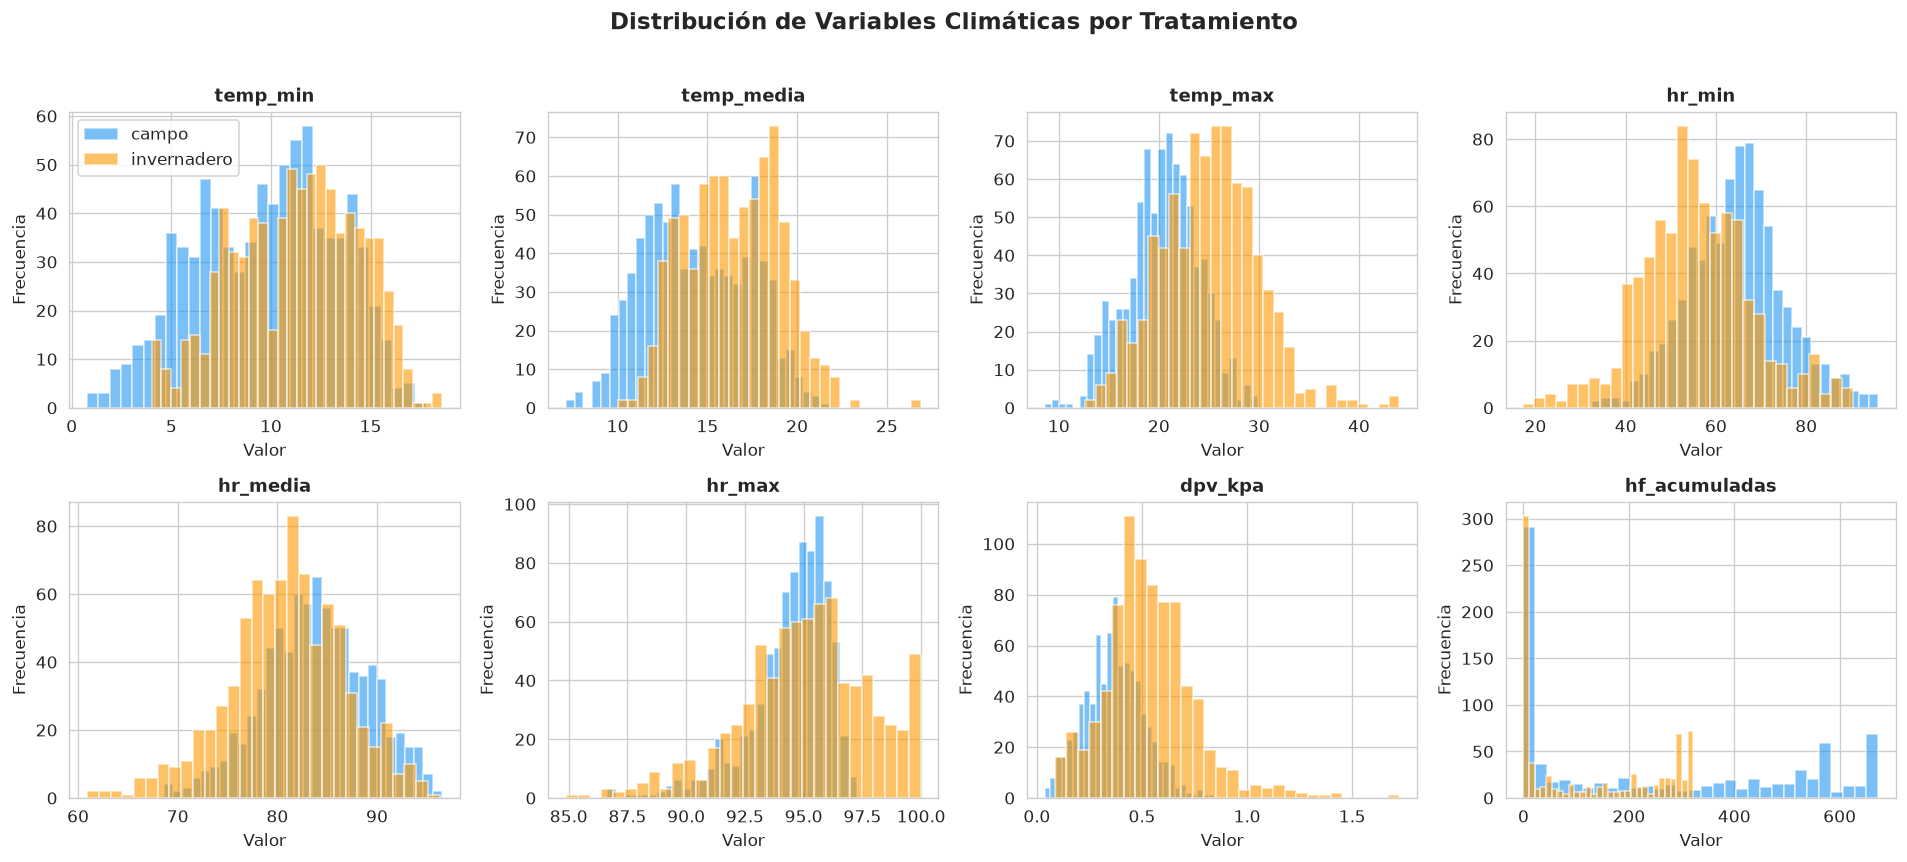

In [5]:
# Distribución de variables: histogramas
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colores = {'campo': '#2196F3', 'invernadero': '#FF9800'}

for i, var in enumerate(VARS_CLIMATICAS):
    for trat, color in colores.items():
        subset = df[df['tratamiento'] == trat][var].dropna()
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=trat, edgecolor='white')
    axes[i].set_title(var, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    if i == 0:
        axes[i].legend()

plt.suptitle('Distribución de Variables Climáticas por Tratamiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Definición de la Variable Objetivo: `calidad_climatica`

### Umbrales Agronómicos para *Annona cherimola*

Basados en literatura agronómica (INIA Chile, FAO):

| Condición | Calidad |
|-----------|--------|
| temp_media 15–22°C **Y** hr_media 70–90% **Y** dpv_kpa < 0.5 | **Alta** |
| temp_media 12–26°C **Y** hr_media 55–95% **Y** dpv_kpa < 1.0 | **Media** |
| Fuera de los rangos anteriores | **Baja** |

> Las horas frío acumuladas no se usan directamente en el umbral de calidad diaria,  
> pero sí como predictor del modelo.

In [6]:
def clasificar_calidad(row):
    """Clasifica condición climática diaria en Alta/Media/Baja para chirimoya."""
    t = row['temp_media']
    hr = row['hr_media']
    dpv = row['dpv_kpa']

    # Alta: condiciones óptimas
    if (15 <= t <= 22) and (70 <= hr <= 90) and (dpv < 0.5):
        return 'Alta'
    # Media: condiciones aceptables
    elif (12 <= t <= 26) and (55 <= hr <= 95) and (dpv < 1.0):
        return 'Media'
    # Baja: condiciones desfavorables
    else:
        return 'Baja'

df['calidad_climatica'] = df.apply(clasificar_calidad, axis=1)

print('Distribución de calidad climática:')
print(df['calidad_climatica'].value_counts())
print(f'\nProporción:\n{df["calidad_climatica"].value_counts(normalize=True).round(3)}')

Distribución de calidad climática:
calidad_climatica
Media    1001
Alta      371
Baja      292
Name: count, dtype: int64

Proporción:
calidad_climatica
Media    0.602
Alta     0.223
Baja     0.175
Name: proportion, dtype: float64


In [7]:
# Distribución por tratamiento
tabla_cruzada = pd.crosstab(df['tratamiento'], df['calidad_climatica'], margins=True)
print('Calidad por tratamiento:')
tabla_cruzada

Calidad por tratamiento:


calidad_climatica,Alta,Baja,Media,All
tratamiento,,,,
campo,215,221,396,832
invernadero,156,71,605,832
All,371,292,1001,1664


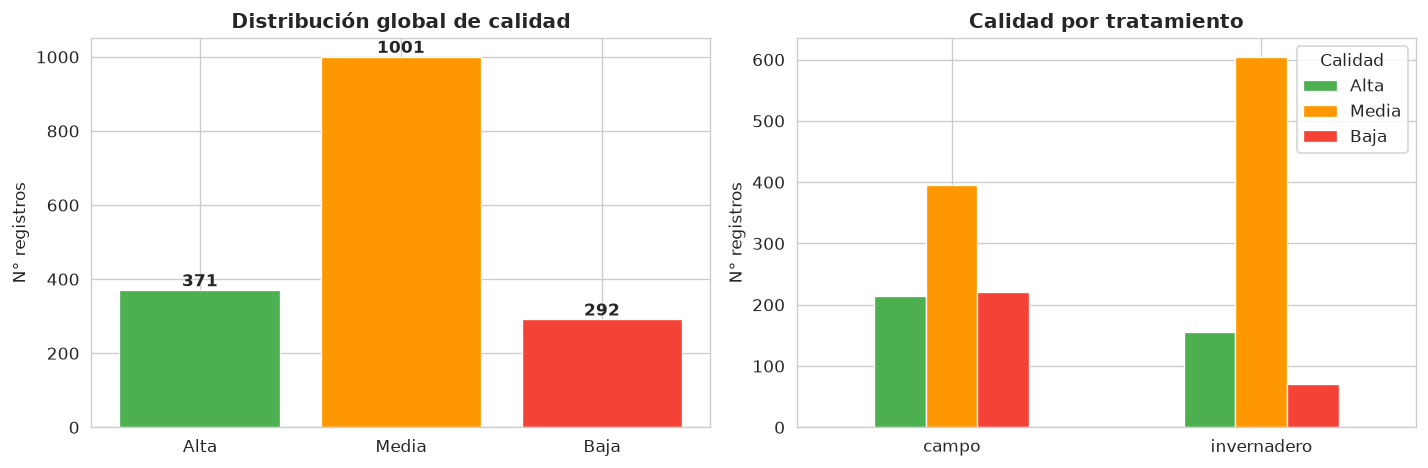

In [8]:
# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orden = ['Alta', 'Media', 'Baja']
colores_cal = ['#4CAF50', '#FF9800', '#F44336']

# Global
conteos = df['calidad_climatica'].value_counts()[orden]
axes[0].bar(conteos.index, conteos.values, color=colores_cal, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribución global de calidad', fontweight='bold')
axes[0].set_ylabel('N° registros')
for i, v in enumerate(conteos.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Por tratamiento
df_pivot = df.groupby(['tratamiento', 'calidad_climatica']).size().unstack(fill_value=0)
df_pivot = df_pivot[orden] if all(c in df_pivot.columns for c in orden) else df_pivot
df_pivot.plot(kind='bar', ax=axes[1], color=colores_cal, edgecolor='white', linewidth=0.8)
axes[1].set_title('Calidad por tratamiento', fontweight='bold')
axes[1].set_ylabel('N° registros')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Calidad')

plt.tight_layout()
plt.show()

---
## 4. Correlaciones entre Variables

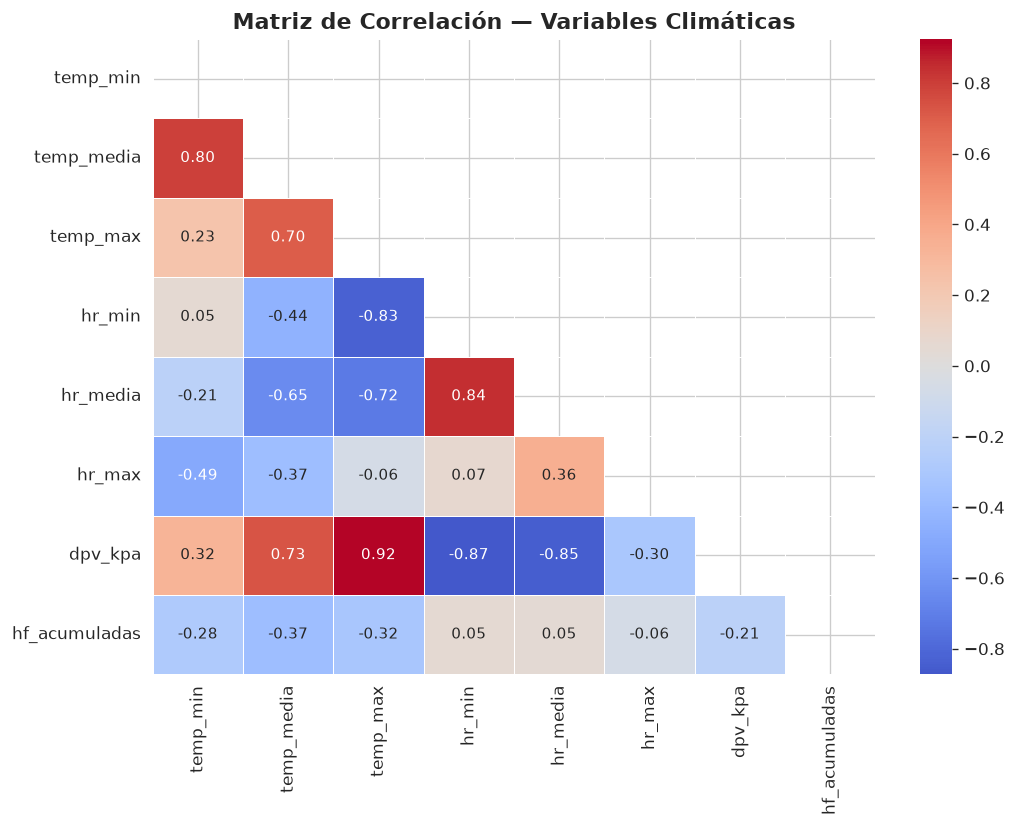

In [9]:
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = df[VARS_CLIMATICAS].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Matriz de Correlación — Variables Climáticas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Preparación de Datos para Modelado

In [10]:
# Features: variables climáticas + tratamiento codificado
df_modelo = df[VARS_CLIMATICAS + ['tratamiento', 'calidad_climatica']].dropna()

# Codificar tratamiento (campo=0, invernadero=1)
df_modelo = df_modelo.copy()
df_modelo['tratamiento_cod'] = (df_modelo['tratamiento'] == 'invernadero').astype(int)

FEATURES = VARS_CLIMATICAS + ['tratamiento_cod']
TARGET   = 'calidad_climatica'

X = df_modelo[FEATURES]
y = df_modelo[TARGET]

print(f'Dataset para modelo: {X.shape[0]} registros, {X.shape[1]} features')
print(f'Clases: {y.unique()}')

Dataset para modelo: 1603 registros, 9 features
Clases: <StringArray>
['Alta', 'Media', 'Baja']
Length: 3, dtype: str


In [11]:
# División entrenamiento / prueba (80/20 estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Escalado (necesario para LR y SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')
print(f'\nDistribución de clases en entrenamiento:')
print(y_train.value_counts())

Entrenamiento: 1282 registros
Prueba:        321 registros

Distribución de clases en entrenamiento:
calidad_climatica
Media    796
Alta     297
Baja     189
Name: count, dtype: int64


---
## 6. Entrenamiento de Modelos

Se comparan 3 algoritmos de clasificación:

| Modelo | Ventaja |
|--------|--------|
| **Random Forest** | Robusto, maneja no-linealidades, entrega importancia de variables |
| **Regresión Logística** | Interpretable, línea base sólida |
| **SVM (kernel RBF)** | Potente en espacios de alta dimensión |

In [12]:
modelos = {
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=SEED),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=SEED)
}

resultados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for nombre, modelo in modelos.items():
    # Usar datos escalados para LR y SVM, sin escalar para RF
    if nombre == 'Random Forest':
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_sc, X_test_sc

    # Validación cruzada 5-fold
    cv_scores = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

    # Entrenar y evaluar en test
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro')

    resultados[nombre] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'X_te':   X_te,
        'accuracy': acc,
        'f1_macro': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std()
    }

    print(f'[{nombre}]  Accuracy: {acc:.3f} | F1-macro: {f1:.3f} | CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

[Random Forest]  Accuracy: 0.991 | F1-macro: 0.989 | CV F1: 0.992 ± 0.007
[Regresión Logística]  Accuracy: 0.854 | F1-macro: 0.828 | CV F1: 0.838 ± 0.045


[SVM (RBF)]  Accuracy: 0.897 | F1-macro: 0.883 | CV F1: 0.934 ± 0.014


---
## 7. Comparación de Modelos

In [13]:
# Tabla resumen
resumen = pd.DataFrame({
    'Modelo':    list(resultados.keys()),
    'Accuracy':  [v['accuracy'] for v in resultados.values()],
    'F1-macro':  [v['f1_macro'] for v in resultados.values()],
    'CV F1 (media)': [v['cv_mean'] for v in resultados.values()],
    'CV F1 (±std)':  [v['cv_std']  for v in resultados.values()]
}).set_index('Modelo').sort_values('F1-macro', ascending=False)

resumen.round(4)

,Accuracy,F1-macro,CV F1 (media),CV F1 (±std)
Modelo,,,,
Random Forest,0.9907,0.9894,0.9917,0.0066
SVM (RBF),0.8972,0.8831,0.9343,0.0135
Regresión Logística,0.8536,0.8284,0.8380,0.0454


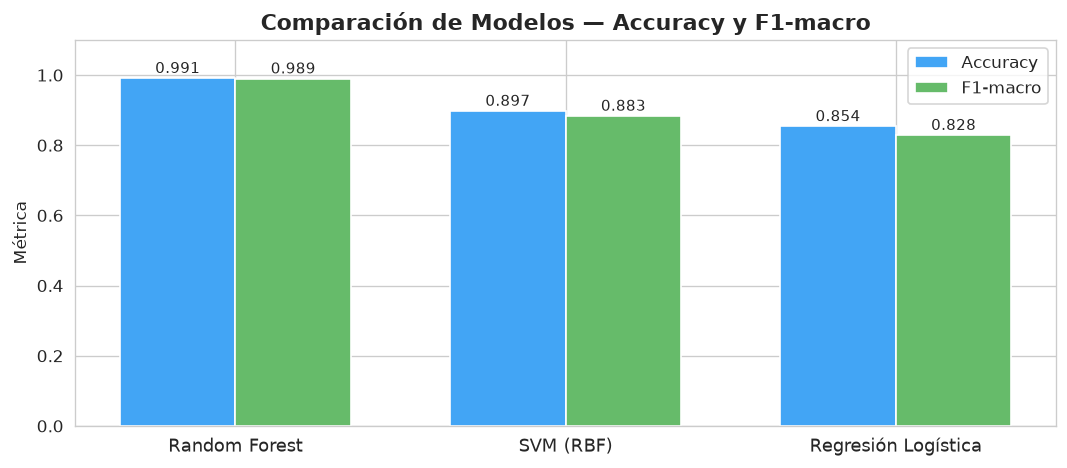

In [14]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(resumen))
w = 0.35
bars1 = ax.bar(x - w/2, resumen['Accuracy'],  w, label='Accuracy',  color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x + w/2, resumen['F1-macro'],  w, label='F1-macro',  color='#66BB6A', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(resumen.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Métrica')
ax.set_title('Comparación de Modelos — Accuracy y F1-macro', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Evaluación Detallada — Mejor Modelo

In [15]:
# Seleccionar mejor modelo por F1-macro
mejor_nombre = resumen['F1-macro'].idxmax()
mejor = resultados[mejor_nombre]

print(f'🏆 Mejor modelo: {mejor_nombre}')
print(f'   Accuracy : {mejor["accuracy"]:.4f}')
print(f'   F1-macro : {mejor["f1_macro"]:.4f}')
print()
print(classification_report(y_test, mejor['y_pred'], target_names=['Alta', 'Baja', 'Media']))

🏆 Mejor modelo: Random Forest
   Accuracy : 0.9907
   F1-macro : 0.9894

              precision    recall  f1-score   support

        Alta       0.99      0.99      0.99        74
        Baja       1.00      0.98      0.99        47
       Media       0.99      0.99      0.99       200

    accuracy                           0.99       321
   macro avg       0.99      0.99      0.99       321
weighted avg       0.99      0.99      0.99       321



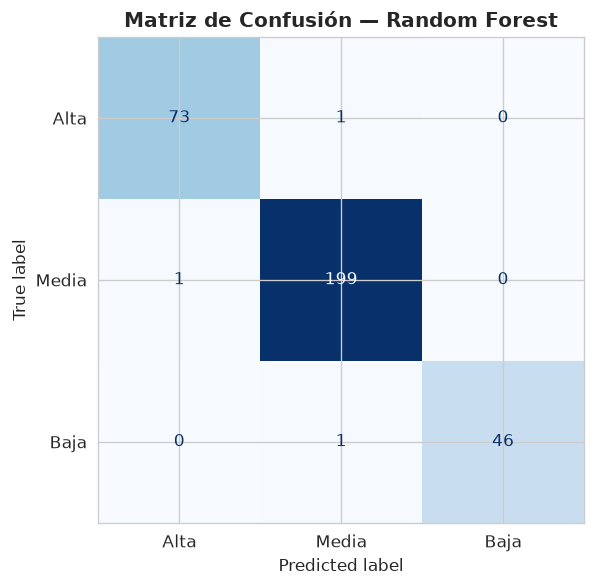

In [16]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, mejor['y_pred'], labels=['Alta', 'Media', 'Baja'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alta', 'Media', 'Baja'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusión — {mejor_nombre}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Importancia de Variables (Random Forest)

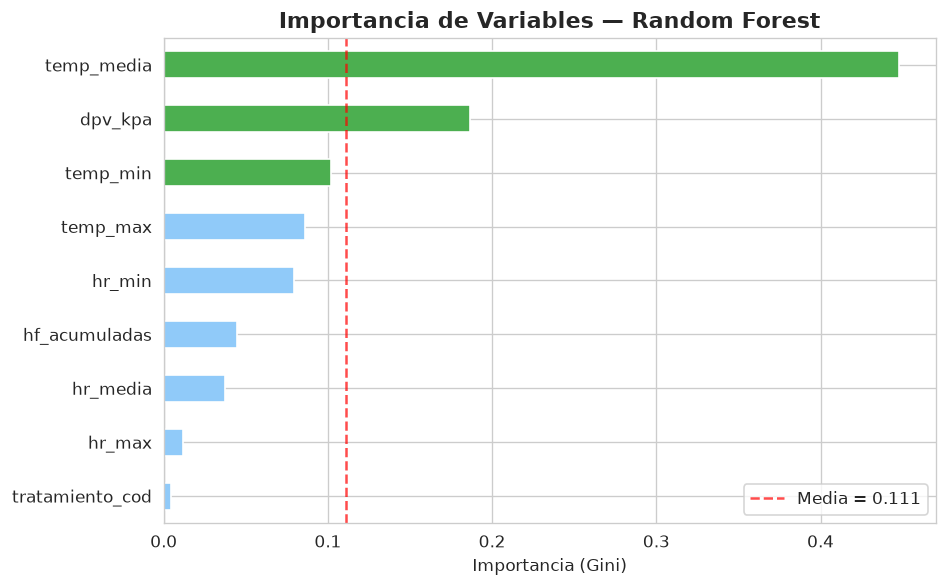

Variables más influyentes (importancia > media):
temp_media    0.447908
dpv_kpa       0.186393
dtype: float64


In [17]:
rf_model = resultados['Random Forest']['modelo']

importancias = pd.Series(
    rf_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4CAF50' if v > 0.1 else '#90CAF9' for v in importancias.values]
importancias.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
ax.axvline(importancias.mean(), color='red', linestyle='--', alpha=0.7, label=f'Media = {importancias.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print('Variables más influyentes (importancia > media):')
print(importancias[importancias > importancias.mean()].sort_values(ascending=False))

---
## 10. Análisis por Tratamiento

In [18]:
# Comparar calidad predicha por tratamiento en el conjunto de prueba
df_test = X_test.copy()
df_test['calidad_real']     = y_test.values
df_test['calidad_predicha'] = mejor['y_pred']
df_test['tratamiento']      = df_test['tratamiento_cod'].map({0: 'campo', 1: 'invernadero'})

tabla_trat = pd.crosstab(
    df_test['tratamiento'],
    df_test['calidad_predicha'],
    margins=True
)
print('Calidad predicha por tratamiento (conjunto de prueba):')
tabla_trat

Calidad predicha por tratamiento (conjunto de prueba):


calidad_predicha,Alta,Baja,Media,All
tratamiento,,,,
campo,44,37,88,169
invernadero,30,9,113,152
All,74,46,201,321


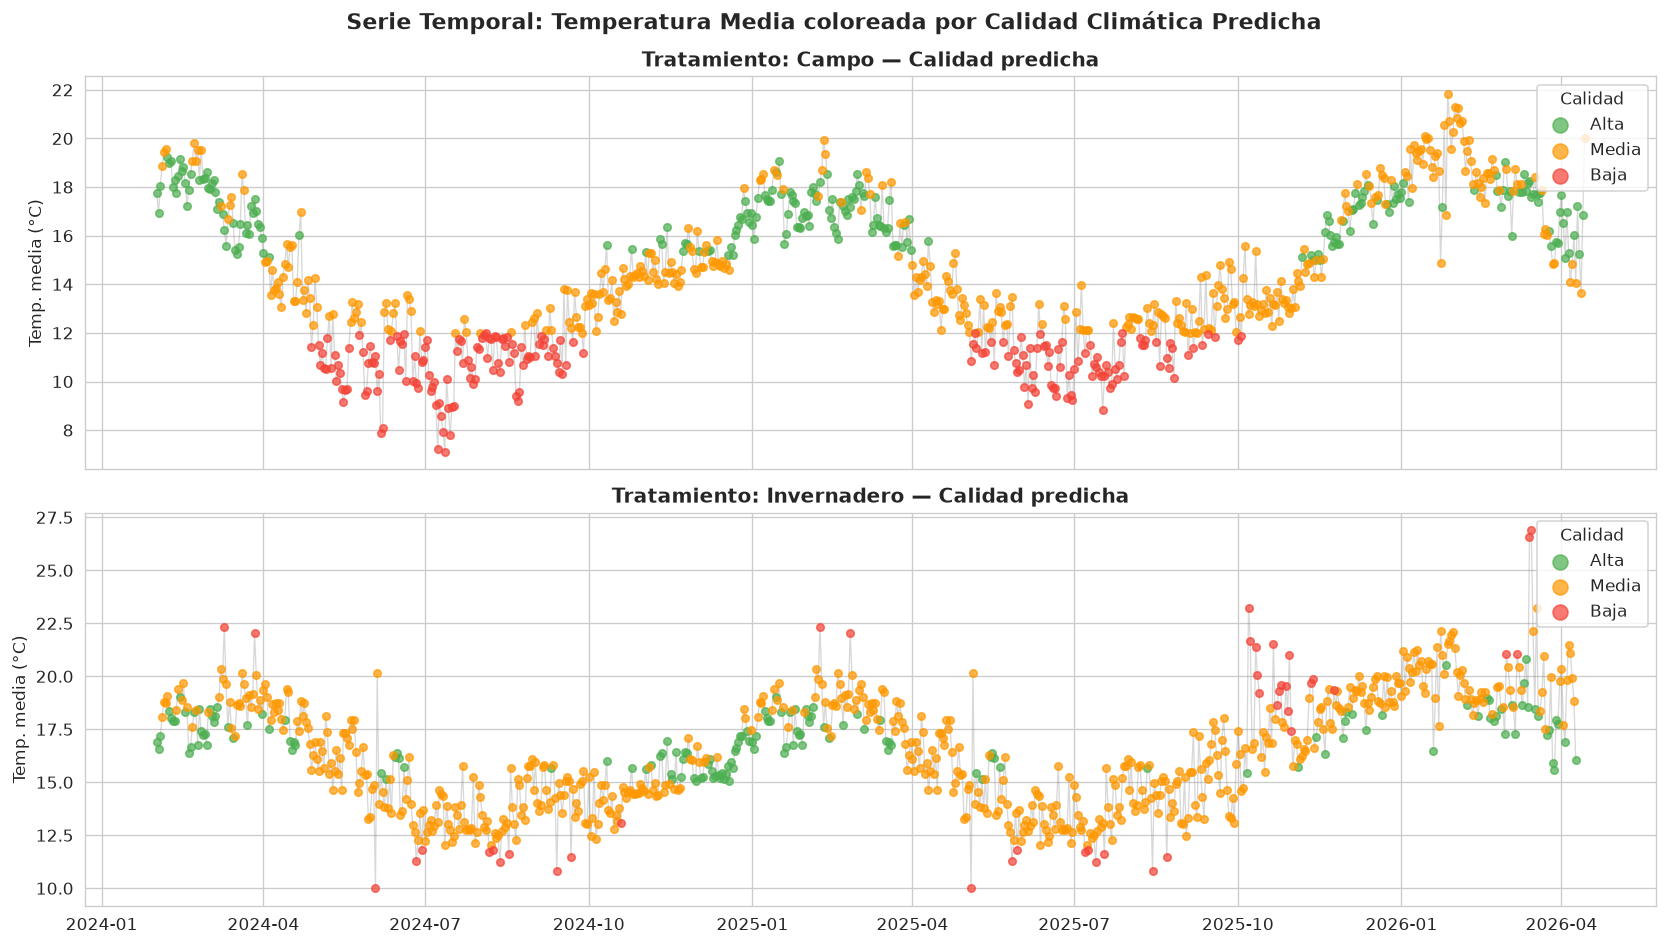

In [19]:
# Serie temporal de calidad predicha (datos completos)
df_full = df_modelo.copy()

# Obtener predicciones del mejor modelo para todo el dataset
if mejor_nombre == 'Random Forest':
    X_all = df_full[FEATURES]
else:
    X_all = scaler.transform(df_full[FEATURES])

df_full['calidad_pred'] = resultados[mejor_nombre]['modelo'].predict(X_all)
df_full['fecha'] = df.loc[df_modelo.index, 'fecha'].values

mapa_color = {'Alta': '#4CAF50', 'Media': '#FF9800', 'Baja': '#F44336'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, trat in zip(axes, ['campo', 'invernadero']):
    sub = df_full[df_full['tratamiento'] == trat].sort_values('fecha')
    for cal, color in mapa_color.items():
        mask = sub['calidad_pred'] == cal
        ax.scatter(sub.loc[mask, 'fecha'], sub.loc[mask, 'temp_media'],
                   c=color, label=cal, s=20, alpha=0.7, zorder=3)
    ax.plot(sub['fecha'], sub['temp_media'], color='gray', alpha=0.3, linewidth=0.8, zorder=2)
    ax.set_ylabel('Temp. media (°C)')
    ax.set_title(f'Tratamiento: {trat.capitalize()} — Calidad predicha', fontweight='bold')
    ax.legend(title='Calidad', loc='upper right', markerscale=2)

plt.suptitle('Serie Temporal: Temperatura Media coloreada por Calidad Climática Predicha',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Conclusiones

### Resumen del análisis:

1. **Variable objetivo:** `calidad_climatica` definida con umbrales agronómicos para *Annona cherimola*:
   - **Alta:** temp_media 15–22°C, hr_media 70–90%, DPV < 0.5 kPa
   - **Media:** temp_media 12–26°C, hr_media 55–95%, DPV < 1.0 kPa
   - **Baja:** condiciones fuera de los rangos anteriores

2. **Mejor modelo:** Ver celda 8 para el resultado definitivo.

3. **Variables más importantes** (según Random Forest):
   - Las variables de temperatura y DPV suelen dominar la clasificación
   - La humedad relativa complementa la distinción entre Media y Baja

4. **Diferencias campo vs invernadero:**
   - El invernadero tiende a mantener condiciones más estables (mayor proporción Alta/Media)
   - El campo muestra mayor variabilidad estacional

### Próximos pasos sugeridos:
- Ajustar los umbrales de calidad con expertos agrónomos de chirimoya
- Incorporar `par` (radiación PAR) cuando esté disponible
- Explorar modelos de serie temporal (LSTM) para capturar dependencias temporales
- Validar el modelo con datos de una temporada nueva (2025)